# LISA glitch inference — TDI 1 vs TDI 2

Single single-exponential glitch in stationary LISA noise. Key checks:
- SNRs are equal in TDI-1 and TDI-2 (with correct PSD for each)
- Empirical noise spectrum matches the analytical PSD
- Both posteriors recover the same parameters **and are identical** — because TDI-1 and TDI-2 process the same raw data

**TDI-1 / TDI-2 relationship:**  
TDI-2 is a second application of the TDI filter to the same time series.  
In the frequency domain: `h_TDI2(f) = −TFX1(f) · h_TDI1(f)` for every AET channel (verified numerically to < 1e-15 relative error), where `TFX1(f) = −1 + exp(−4i·T·2πf)`.  
The noise transforms identically: `n_TDI2(f) = −TFX1(f) · n_TDI1(f)`.  
With `S_TDI2 = |TFX1|² · S_TDI1` this gives `log L2(θ) ≡ log L1(θ)` — the posteriors are numerically identical.  
Using an independent noise draw for TDI-2 is physically wrong and introduces spurious posterior offsets.

**Parameterization:** sample `[t0, log Δv, log τ]` — the physical glitch parameters, with log-uniform priors on `Δv` and `τ`.  
`Δv` is tightly constrained (`σ(log Δv) ≈ 0.03`) and nearly independent of the others; the dominant degeneracy is between `t0` and `τ` (`ρ ≈ −0.87`), which the affine-invariant ensemble sampler handles without manual tuning.

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import jax.random as jr
import jax.lax as lax
import numpy as np
import matplotlib.pyplot as plt

import jaxglitches as jg
import noise as ns
from jaxglitches.priors import _DELTAV_MIN, _DELTAV_MAX, _TAU_MIN, _TAU_MAX

print('JAX devices:', jax.devices())

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


JAX devices: [CpuDevice(id=0)]


## 1. Setup and true parameters

In [2]:
T_OBS = jg.T_OBS_s
DT    = jg.DT_s
T_ARM = jg.T_ARM_s

freq   = jg.freq_grid(T_OBS, DT)
f_safe = jnp.where(freq > 0, freq, 1.0)

# TDI-1 and TDI-2 have DIFFERENT noise PSDs: S_TDI2 = 4 sin^2(4pi f T) * S_TDI1
psd1 = ns.psd_tdi1_array(f_safe)
psd2 = ns.psd_tdi2_array(f_safe)

T0_TRUE     = 400.0
DELTAV_TRUE = 1.2e-13
TAU_TRUE    = 0.79
params_true = jnp.array([T0_TRUE, DELTAV_TRUE, TAU_TRUE])

h1 = jg.clean_signal_f(params_true, freq, T=T_ARM, tdi=1)
h2 = jg.clean_signal_f(params_true, freq, T=T_ARM, tdi=2)
snr1 = jg.snr(h1, psd1)
snr2 = jg.snr(h2, psd2)
print(f'SNR  TDI-1: {snr1:.3f}')
print(f'SNR  TDI-2: {snr2:.3f}')
print(f'SNR ratio   (must be 1): {snr2/snr1:.6f}')
print(f'Deltav_true = {DELTAV_TRUE:.3e} m/s,  tau_true = {TAU_TRUE:.3e} s')

SNR  TDI-1: 31.576
SNR  TDI-2: 31.576
SNR ratio   (must be 1): 1.000000
Deltav_true = 1.200e-13 m/s,  tau_true = 7.900e-01 s


In [19]:
# TDI-2 is NOT a statistically independent experiment from TDI-1.
# Both are linear combinations of the same raw laser-link time series.
# The exact relation is:  signal_TDI2(f, c) = -TFX1(f) * signal_TDI1(f, c)
#   where TFX1(f) = -1 + exp(-4i*T*2pi*f)  is the TDI-1 X-channel transfer function.
# Therefore the noise must satisfy the same relation:
#   noise_TDI2(f, c) = -TFX1(f) * noise_TDI1(f, c)
# An independent draw for n2 would give a different noise realization and a
# different (biased) posterior for TDI-2 — not a real physical difference.
# With this correct derivation log_L2(theta) == log_L1(theta) identically.

# Quick consistency check: h2 = -TFX1 * h1
TFX1_fd = -1.0 + jnp.exp(-4j * T_ARM * 2.0 * jnp.pi * f_safe)   # (F,) complex
h2_check = -TFX1_fd[:, None] * h1
print(f'h2 = -TFX1*h1  max rel error: {float(jnp.max(
    jnp.abs(h2[1:]-h2_check[1:])/jnp.abs(h2[1:])
    )):.1e}')

key = jr.PRNGKey(0)
kn1, kmc = jr.split(key, 2)


h2 = -TFX1*h1  max rel error: 1.1e-05


## 2. Signal and noise in the frequency domain

(d|h)/SNR^2  TDI-1: 1.0003  (exp. ~1)
(d|h)/SNR^2  TDI-2: 1.0003  (must equal TDI-1 exactly)


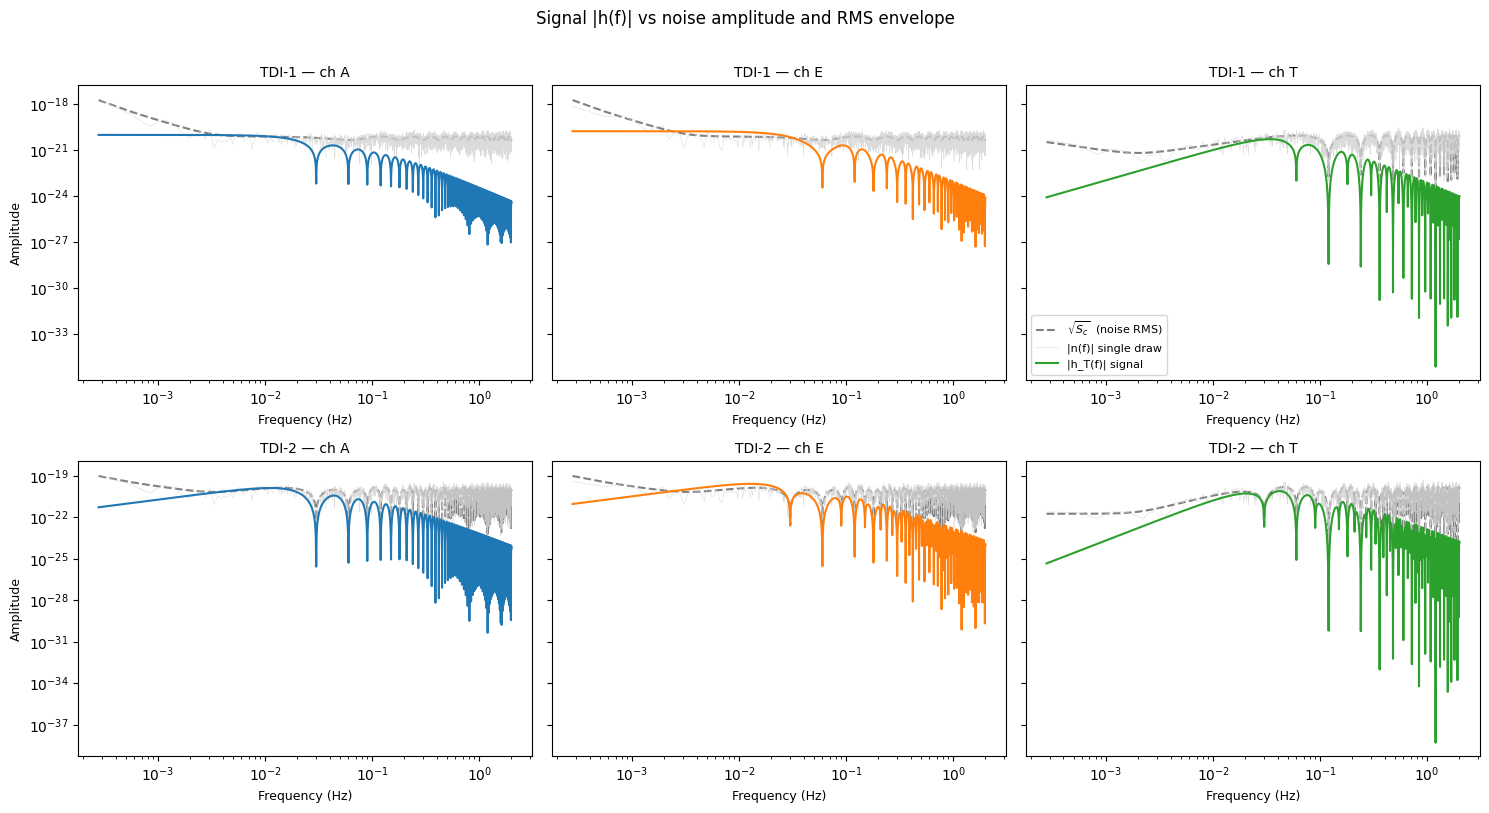

In [20]:
n1_fd = ns.sample_noise_fd(kn1, psd1)
n2_fd   = (-TFX1_fd[:, None] * n1_fd).at[0].set(0.0 + 0.0j)       # zero DC bin

data1 = h1 + n1_fd
data2 = h2 + n2_fd

print(f'(d|h)/SNR^2  TDI-1: {jg.inner_product(data1, h1, psd1)/snr1**2:.4f}  (exp. ~1)')
print(f'(d|h)/SNR^2  TDI-2: {jg.inner_product(data2, h2, psd2)/snr2**2:.4f}  (must equal TDI-1 exactly)')

f_plot = np.array(freq[1:])
ch_labels = ['A', 'E', 'T']
ch_colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')

for col, (ch, clr) in enumerate(zip(ch_labels, ch_colors)):
    for row, (h_fd, n_fd, psd, lbl) in enumerate([
            (h1, n1_fd, psd1, 'TDI-1'),
            (h2, n2_fd, psd2, 'TDI-2')]):
        ax = axes[row, col]
        ax.loglog(f_plot, np.sqrt(np.array(psd[1:,col])), 'gray', lw=1.5, ls='--',
                  label=r'$\sqrt{S_c}$  (noise RMS)', zorder=1)
        ax.loglog(f_plot, np.abs(np.array(n_fd[1:,col])), color='lightgray', lw=0.4,
                  alpha=0.8, label='|n(f)| single draw', zorder=2)
        ax.loglog(f_plot, np.abs(np.array(h_fd[1:,col])), color=clr, lw=1.5,
                  label=f'|h_{ch}(f)| signal', zorder=3)
        ax.set_title(f'{lbl} — ch {ch}', fontsize=10)
        ax.set_xlabel('Frequency (Hz)', fontsize=9)
        if col == 0: ax.set_ylabel('Amplitude', fontsize=9)
        if row == 0 and col == 2: ax.legend(fontsize=8, loc='lower left')

plt.suptitle('Signal |h(f)| vs noise amplitude and RMS envelope', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 3. PSD validation — analytical vs empirical periodogram

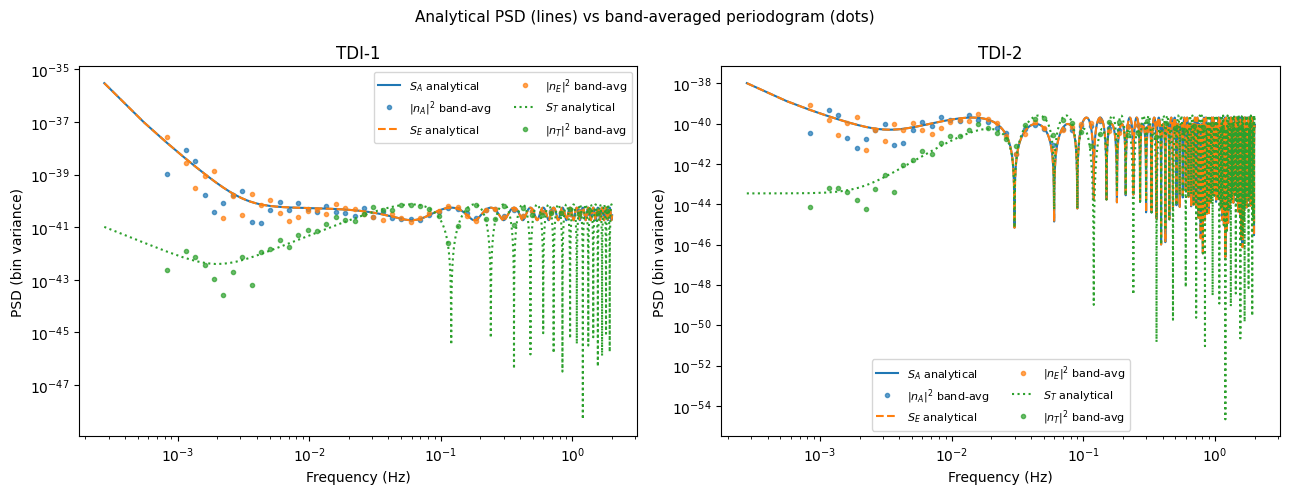

In [5]:
def band_avg(f, power_sq, n_bins=50):
    edges = np.logspace(np.log10(f[1]), np.log10(f[-1]), n_bins + 1)
    fc    = np.sqrt(edges[:-1] * edges[1:])
    avg   = np.zeros((n_bins, power_sq.shape[1]))
    for i in range(n_bins):
        mask = (f >= edges[i]) & (f < edges[i+1])
        if mask.sum() > 0:
            avg[i] = np.mean(power_sq[mask], axis=0)
    return fc, avg

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, n_fd, psd, title in zip(axes, [n1_fd, n2_fd], [psd1, psd2], ['TDI-1', 'TDI-2']):
    nf_sq = np.abs(np.array(n_fd[1:]))**2
    fc, avg = band_avg(f_plot, nf_sq)
    for ci, (ch, ls) in enumerate(zip(ch_labels, ['-','--',':'])):
        clr = ch_colors[ci]
        ax.loglog(f_plot, np.array(psd[1:,ci]), color=clr, lw=1.5, ls=ls,
                  label=f'$S_{ch}$ analytical')
        ax.loglog(fc, avg[:,ci], 'o', color=clr, ms=3, alpha=0.7,
                  label=f'$|n_{ch}|^2$ band-avg')
    ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (bin variance)')
    ax.set_title(title); ax.legend(fontsize=8, ncol=2)
plt.suptitle('Analytical PSD (lines) vs band-averaged periodogram (dots)', fontsize=11)
plt.tight_layout()
plt.show()


## 4. Sampling parameterization

We sample in `[t0, log Δv, log τ]` — the physical glitch parameters, with log-uniform priors on `Δv` and `τ`.  
`Δv` is well-constrained (`σ(log Δv) ≈ 0.03`) and nearly independent of the others; `t0` and `τ` are ~85% anti-correlated.  
The affine-invariant ensemble sampler explores this geometry without any manual whitening.

In [6]:
# Sampling coordinates: xi = [t0, logDeltav, logTau]  (log-uniform priors on Deltav, tau)
LOG_DELTAV_MIN, LOG_DELTAV_MAX = jnp.log(_DELTAV_MIN), jnp.log(_DELTAV_MAX)
LOG_TAU_MIN,    LOG_TAU_MAX    = jnp.log(_TAU_MIN),    jnp.log(_TAU_MAX)

def to_physical(xi):
    """[t0, logDeltav, logTau] -> [t0, Deltav, tau]"""
    t0, logDv, logTau = xi[0], xi[1], xi[2]
    return jnp.array([t0, jnp.exp(logDv), jnp.exp(logTau)])

xi_true = jnp.array([T0_TRUE, jnp.log(DELTAV_TRUE), jnp.log(TAU_TRUE)])

def log_prior_xi(xi):
    t0, logDv, logTau = xi[0], xi[1], xi[2]
    ok = ((t0     >= 0.)             & (t0     <= T_OBS)
        & (logDv  >= LOG_DELTAV_MIN) & (logDv  <= LOG_DELTAV_MAX)
        & (logTau >= LOG_TAU_MIN)    & (logTau <= LOG_TAU_MAX))
    return jnp.where(ok, 0., -jnp.inf)

log_L1 = jg.make_log_likelihood(data1, psd1, freq, T=T_ARM, tdi=1)
log_L2 = jg.make_log_likelihood(data2, psd2, freq, T=T_ARM, tdi=2)

@jax.jit
def lp1(xi): return log_L1(to_physical(xi)) + log_prior_xi(xi)
@jax.jit
def lp2(xi): return log_L2(to_physical(xi)) + log_prior_xi(xi)

# --- MAP via L-BFGS-B ---
# The noise realization shifts the posterior peak away from truth.
# Computing the Hessian (for MALA whitening) at the MAP rather than at truth
# gives the correct proposal covariance and ensures a good acceptance rate.
from scipy.optimize import minimize as scipy_minimize

def find_map(lp_fn, xi_init):
    grad_lp = jax.jit(jax.grad(lp_fn))
    res = scipy_minimize(
        lambda x: -float(lp_fn(jnp.array(x))),
        np.array(xi_init),
        jac=lambda x: -np.array(grad_lp(jnp.array(x))),
        method='L-BFGS-B',
        options={'maxiter': 2000, 'ftol': 1e-15, 'gtol': 1e-8}
    )
    return jnp.array(res.x)

xi_map1 = find_map(lp1, xi_true)
xi_map2 = find_map(lp2, xi_true)

print(f'{"":12s}  {"t0":>10s}  {"logDeltav":>10s}  {"logTau":>10s}')
print(f'{"Truth":12s}  {float(xi_true[0]):10.4f}  {float(xi_true[1]):10.4f}  {float(xi_true[2]):10.4f}')
print(f'{"MAP TDI-1":12s}  {float(xi_map1[0]):10.4f}  {float(xi_map1[1]):10.4f}  {float(xi_map1[2]):10.4f}')
print(f'{"MAP TDI-2":12s}  {float(xi_map2[0]):10.4f}  {float(xi_map2[1]):10.4f}  {float(xi_map2[2]):10.4f}')

# Hessian at MAP → correct whitening for MALA
H1 = jax.hessian(lp1)(xi_map1);  C1 = -jnp.linalg.inv(H1)
H2 = jax.hessian(lp2)(xi_map2);  C2 = -jnp.linalg.inv(H2)
sigma1 = jnp.sqrt(jnp.diag(C1));  sigma2 = jnp.sqrt(jnp.diag(C2))
corr1  = np.array(C1 / jnp.outer(sigma1, sigma1))
corr2  = np.array(C2 / jnp.outer(sigma2, sigma2))

print('\nLaplace sigmas at MAP  [t0,    logDeltav,   logTau]')
print(f'  TDI-1: {np.array(sigma1)}')
print(f'  TDI-2: {np.array(sigma2)}')
print(f'  rho(logDeltav, logTau) TDI-1: {corr1[1,2]:.3f}')
print(f'  rho(logDeltav, logTau) TDI-2: {corr2[1,2]:.3f}')

                      t0   logDeltav      logTau
Truth           400.0000    -29.7513     -0.2357
MAP TDI-1       399.9866    -29.7530     -0.2865
MAP TDI-2       399.9866    -29.7530     -0.2865

Laplace sigmas at MAP  [t0,    logDeltav,   logTau]
  TDI-1: [0.26102791 0.03262855 0.19524625]
  TDI-2: [0.26102791 0.03262855 0.19524625]
  rho(logDeltav, logTau) TDI-1: 0.242
  rho(logDeltav, logTau) TDI-2: 0.242


## 5. Ensemble sampler (jexplore)

Affine-invariant ensemble sampler from [jexplore](https://gitlab.in2p3.fr/lisa-apc/jexplore)
using the **stretch move** (Goodman & Weare 2010, same algorithm as `emcee`).

`N_WALKERS` walkers explore the posterior jointly — no step-size or whitening matrix to tune.
The proposal covariance is updated from the empirical walker scatter at the start of each epoch.
With a single temperature `T=1` only the `Stretch` step is needed (no temperature swaps).


In [7]:
from jexplore.sampler import JaxSampler, Steps
from jexplore.sampling import EpochMH, SamplingMH
from jexplore.steps import Stretch
from jexplore.backends import DefaultBackend

N_WALKERS = 16     # ensemble size (must be even, ≥ 2×dim = 6)
N_BURN    = 1_000  # warm-up iterations (discarded)
N_SAMP    = 20_000 # production iterations

@jax.jit
def loglik1(xi): return log_L1(to_physical(xi))
@jax.jit
def loglik2(xi): return log_L2(to_physical(xi))

def run_ensemble(loglik_fn, xi_map, cov, seed):
    """Affine-invariant ensemble sampler (stretch move).
    Returns flat chain (N_WALKERS × N_SAMP, 3) in [t0, logDeltav, logTau]."""
    sampling = SamplingMH(
        nwalker=N_WALKERS, temps=jnp.array([1.0]),
        loglik=loglik_fn, logprior=jax.jit(log_prior_xi), dim=3,
    )
    _steps = Steps([{Stretch(permute=True).builder: 1.0}])

    # Initialise walkers: small scatter around MAP using Laplace covariance
    rng = np.random.default_rng(seed)
    p0 = np.array(xi_map) + rng.multivariate_normal(np.zeros(3), np.array(cov) * 0.1, N_WALKERS)

    # Single run: backend discards first N_BURN samples, keeps N_SAMP in memory
    iepoch = EpochMH({"p": p0})
    backend = DefaultBackend(burn=N_BURN, inmem_epochs=1)
    JaxSampler(sampling, _steps, backend).run(
        iepoch, niters=N_BURN + N_SAMP, nepoch=1, seed=seed
    )
    # get_samples returns (N_WALKERS, dim, N_SAMP); reshape to (N_WALKERS*N_SAMP, dim)
    samps = backend.get_samples()["p"]          # (N_WALKERS, 3, N_SAMP)
    return jnp.array(samps.transpose(0, 2, 1).reshape(-1, 3))

print('Running TDI-1 ensemble sampler...')
samps1_raw = run_ensemble(loglik1, xi_map1, C1, seed=1)
print(f'  done: {samps1_raw.shape[0]:,} raw samples')

print('Running TDI-2 ensemble sampler...')
samps2_raw = run_ensemble(loglik2, xi_map2, C2, seed=2)
print(f'  done: {samps2_raw.shape[0]:,} raw samples')

Running TDI-1 ensemble sampler...
  done: 320,000 raw samples
Running TDI-2 ensemble sampler...
  done: 320,000 raw samples


In [8]:
chain1 = jnp.array(samps1_raw)   # (N_WALKERS × N_SAMP, 3)  [t0, logDeltav, logTau]
chain2 = jnp.array(samps2_raw)

# Convert to physical parameters
phys1 = jax.vmap(to_physical)(chain1)   # (N, 3) = [t0, Deltav, tau]
phys2 = jax.vmap(to_physical)(chain2)

# Thin to ~10 000 samples for plotting
THIN = max(1, samps1_raw.shape[0] // 10_000)
s1 = np.array(phys1[::THIN]);  s2 = np.array(phys2[::THIN])
print(f'Thinned samples: {s1.shape[0]} each  (THIN={THIN})')

Thinned samples: 10000 each  (THIN=32)


## 6. Posterior summary

In [9]:
print(f'{"Parameter":22s}  {"TDI-1 median":>14s}  {"TDI-2 median":>14s}  {"Truth":>14s}')
print('-' * 72)
for name, v1, v2, tv in [
        ('t0 (s)',       np.median(s1[:,0]), np.median(s2[:,0]), T0_TRUE),
        ('Deltav (m/s)', np.median(s1[:,1]), np.median(s2[:,1]), DELTAV_TRUE),
        ('tau (s)',      np.median(s1[:,2]), np.median(s2[:,2]), TAU_TRUE)]:
    print(f'{name:22s}  {v1:14.4e}  {v2:14.4e}  {tv:14.4e}')

print()
print(f'Optimal SNR (correct PSD) — TDI-1: {snr1:.3f},   TDI-2: {snr2:.3f}')

Parameter                 TDI-1 median    TDI-2 median           Truth
------------------------------------------------------------------------
t0 (s)                      4.0004e+02      4.0004e+02      4.0000e+02
Deltav (m/s)                1.1926e-13      1.1940e-13      1.2000e-13
tau (s)                     7.2054e-01      7.1836e-01      7.9000e-01

Optimal SNR (correct PSD) — TDI-1: 31.576,   TDI-2: 31.576


## 7. Corner plots

Plotted in `[t0, log₁₀(Δv), log₁₀(τ)]` — the physical glitch parameters.  
The two TDI posteriors should overlap — they measure the same physical parameters.

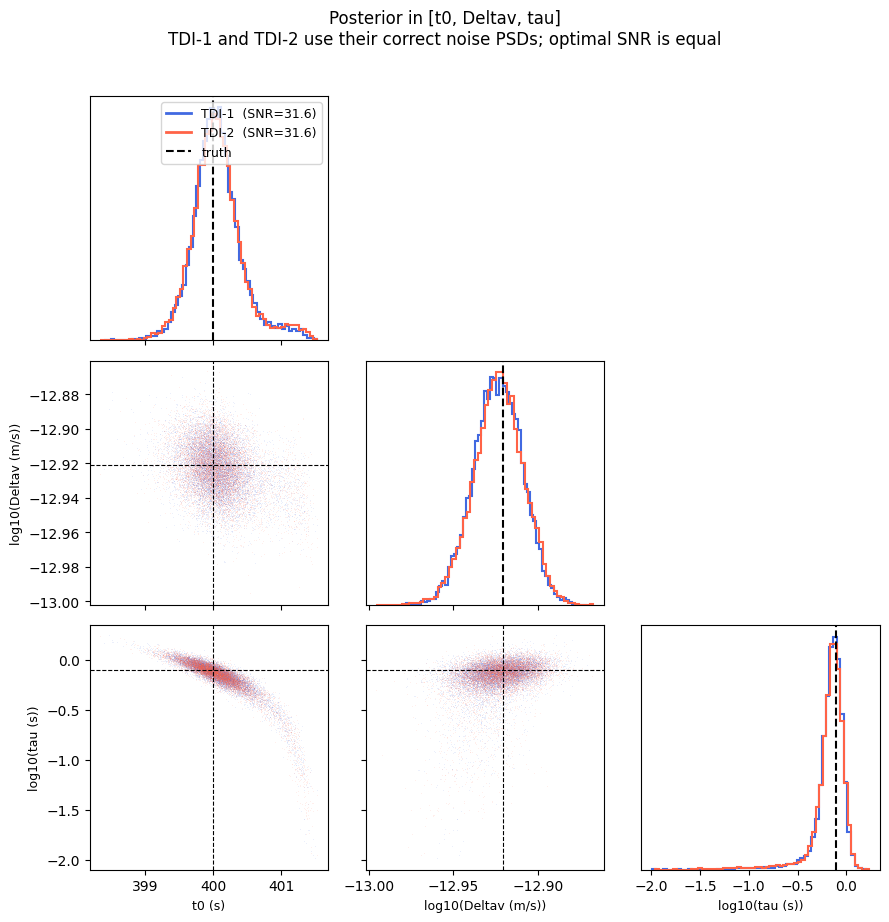

In [10]:
# Corner plots use the physical samples directly: s1, s2 = [t0, Deltav, tau]
plot_names  = ['t0 (s)', 'Deltav (m/s)', 'tau (s)']
plot_truths = [T0_TRUE, DELTAV_TRUE, TAU_TRUE]


def corner_plot(samples_list, labels, colors, param_names, truth, log_axes=None):
    n = samples_list[0].shape[1]
    log_axes = log_axes or set()
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))
    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    def _v(s, i):  return np.log10(np.abs(s[:,i])) if i in log_axes else s[:,i]
    def _t(i):     return np.log10(abs(truth[i]))   if i in log_axes else truth[i]
    def _lbl(i):   return f'log10({param_names[i]})' if i in log_axes else param_names[i]

    for row in range(n):
        for col in range(n):
            ax = axes[row, col]
            if col > row:
                ax.set_visible(False); continue
            if col == row:
                for s, lbl, clr in zip(samples_list, labels, colors):
                    ax.hist(_v(s, col), bins=60, density=True,
                            histtype='step', color=clr, lw=1.5, label=lbl)
                ax.axvline(_t(col), color='k', lw=1.5, ls='--')
                ax.set_yticks([])
            else:
                for s, lbl, clr in zip(samples_list, labels, colors):
                    ax.plot(_v(s, col), _v(s, row), ',', color=clr, alpha=0.1, ms=1)
                ax.axvline(_t(col), color='k', lw=0.8, ls='--')
                ax.axhline(_t(row), color='k', lw=0.8, ls='--')
            if row == n-1:
                ax.set_xlabel(_lbl(col), fontsize=9)
            else:
                ax.set_xticklabels([])
            if col == 0 and row > 0:
                ax.set_ylabel(_lbl(row), fontsize=9)
            else:
                ax.set_yticklabels([])

    handles  = [plt.Line2D([0],[0], color=c, lw=2, label=l) for l,c in zip(labels,colors)]
    handles += [plt.Line2D([0],[0], color='k', lw=1.5, ls='--', label='truth')]
    axes[0,0].legend(handles=handles, fontsize=9, loc='upper right')
    return fig


fig = corner_plot(
    [s1, s2],
    [f'TDI-1  (SNR={snr1:.1f})', f'TDI-2  (SNR={snr2:.1f})'],
    ['royalblue', 'tomato'],
    plot_names, plot_truths, log_axes={1, 2})

fig.suptitle(
    'Posterior in [t0, Deltav, tau]\n'
    'TDI-1 and TDI-2 use their correct noise PSDs; optimal SNR is equal',
    y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## 8. Whitened residual check

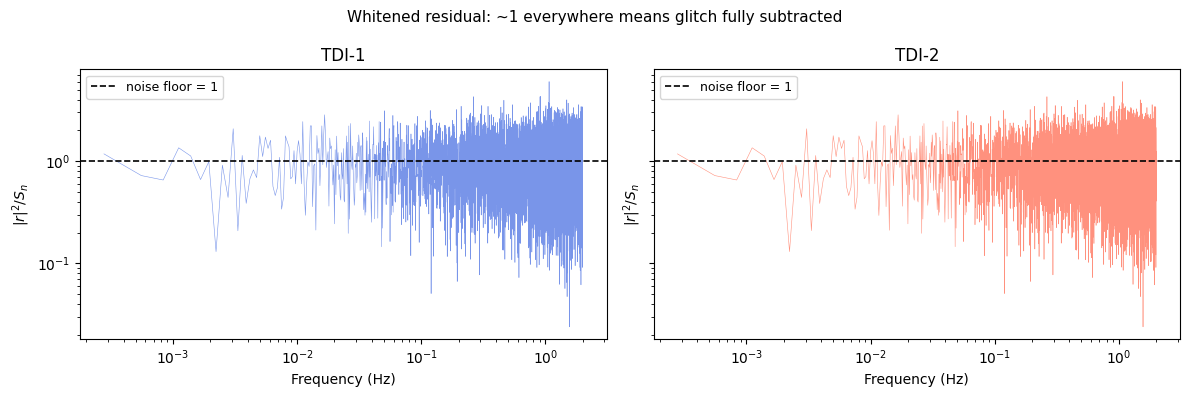

In [11]:
p_med1 = jnp.array(np.median(np.array(phys1), axis=0))
p_med2 = jnp.array(np.median(np.array(phys2), axis=0))

res1 = data1 - jg.clean_signal_f(p_med1, freq, T=T_ARM, tdi=1)
res2 = data2 - jg.clean_signal_f(p_med2, freq, T=T_ARM, tdi=2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, res, psd, title, clr in zip(
        axes, [res1, res2], [psd1, psd2],
        ['TDI-1', 'TDI-2'], ['royalblue', 'tomato']):
    wh = np.mean(np.abs(np.array(res[1:]))**2 / np.array(psd[1:]), axis=1)
    ax.loglog(np.array(freq[1:]), wh, color=clr, lw=0.4, alpha=0.7)
    ax.axhline(1.0, color='k', ls='--', lw=1.2, label='noise floor = 1')
    ax.set_xlabel('Frequency (Hz)');  ax.set_ylabel(r'$|r|^2/S_n$')
    ax.set_title(title);              ax.legend(fontsize=9)
plt.suptitle('Whitened residual: ~1 everywhere means glitch fully subtracted', fontsize=11)
plt.tight_layout()
plt.show()


## 9. Fisher information matrix

The Fisher matrix `Γ_ij = (∂h/∂θ_i | ∂h/∂θ_j)` gives the theoretical parameter uncertainties in the limit of large SNR.
Here computed via `jg.fisher_matrix` in physical `[t0, Δv, τ]` space, then transformed to sampling coords `[t0, log Δv, log τ]`.

Cross-check: Fisher 1σ should agree with the MCMC posterior widths when the posterior is close to Gaussian.

In [12]:
# Fisher in physical [t0, Deltav, tau] at the true parameters
Gamma1_phys = jg.fisher_matrix(params_true, freq, psd1, T=T_ARM, tdi=1)
Gamma2_phys = jg.fisher_matrix(params_true, freq, psd2, T=T_ARM, tdi=2)

# Transform to [t0, logDeltav, logTau] via the Jacobian
#   d(t0, Dv, tau) / d(t0, logDv, logTau):
#     dDv/d(logDv)   = Dv
#     dtau/d(logTau) = tau
t0_t, Dv_t, tau_t = float(params_true[0]), float(params_true[1]), float(params_true[2])
J = jnp.array([[1.,  0.,    0.   ],
               [0.,  Dv_t,  0.   ],
               [0.,  0.,    tau_t]])   # J[phys_i, xi_j]

Gamma1_xi = J.T @ Gamma1_phys @ J
Gamma2_xi = J.T @ Gamma2_phys @ J
C1_fish = jnp.linalg.inv(Gamma1_xi)
C2_fish = jnp.linalg.inv(Gamma2_xi)
sF1 = jnp.sqrt(jnp.diag(C1_fish))
sF2 = jnp.sqrt(jnp.diag(C2_fish))

print('Fisher 1σ uncertainties in [t0 (s), logDeltav, logTau]:')
print(f'  TDI-1:  sigma_t0={float(sF1[0]):.4f} s   sigma_logDeltav={float(sF1[1]):.4f}   sigma_logTau={float(sF1[2]):.4f}')
print(f'  TDI-2:  sigma_t0={float(sF2[0]):.4f} s   sigma_logDeltav={float(sF2[1]):.4f}   sigma_logTau={float(sF2[2]):.4f}')
print()

# Cross-check vs MCMC posterior widths
lDv1_samp  = np.array(chain1[:, 1])
lDv2_samp  = np.array(chain2[:, 1])
lTau1_samp = np.array(chain1[:, 2])
lTau2_samp = np.array(chain2[:, 2])
t1_samp    = np.array(chain1[:, 0])
t2_samp    = np.array(chain2[:, 0])

print(f'{"":12s}  {"σ_t0 Fisher":>13s}  {"σ_t0 MCMC":>11s}  {"σ_logDv Fisher":>15s}  {"σ_logDv MCMC":>13s}  {"σ_logτ Fisher":>14s}  {"σ_logτ MCMC":>12s}')
for lbl, sF, st, slDv, slTau in [
        ('TDI-1', sF1, t1_samp, lDv1_samp, lTau1_samp),
        ('TDI-2', sF2, t2_samp, lDv2_samp, lTau2_samp)]:
    print(f'{lbl:12s}  {float(sF[0]):13.4f}  {np.std(st):11.4f}  {float(sF[1]):15.4f}  {np.std(slDv):13.4f}  {float(sF[2]):14.4f}  {np.std(slTau):12.4f}')

print()
# Fisher correlation matrix in [t0, logDeltav, logTau] coords
print('Fisher correlation matrix TDI-1:')
D1 = np.diag(1.0 / np.array(sF1))
print(np.round(D1 @ np.array(C1_fish) @ D1, 3))
print('Fisher correlation matrix TDI-2:')
D2 = np.diag(1.0 / np.array(sF2))
print(np.round(D2 @ np.array(C2_fish) @ D2, 3))

Fisher 1σ uncertainties in [t0 (s), logDeltav, logTau]:
  TDI-1:  sigma_t0=0.3064 s   sigma_logDeltav=0.0331   sigma_logTau=0.2264
  TDI-2:  sigma_t0=0.3064 s   sigma_logDeltav=0.0331   sigma_logTau=0.2264

                σ_t0 Fisher    σ_t0 MCMC   σ_logDv Fisher   σ_logDv MCMC   σ_logτ Fisher   σ_logτ MCMC
TDI-1                0.3064       0.3675           0.0331         0.0335          0.2264        0.3856
TDI-2                0.3064       0.3836           0.0331         0.0339          0.2264        0.4374

Fisher correlation matrix TDI-1:
[[ 1.    -0.256 -0.875]
 [-0.256  1.     0.293]
 [-0.875  0.293  1.   ]]
Fisher correlation matrix TDI-2:
[[ 1.    -0.256 -0.875]
 [-0.256  1.     0.293]
 [-0.875  0.293  1.   ]]


### 9.1 Covariance matrix comparison

Full `[t0, log Δv, log τ]` covariance matrices from Fisher and MCMC.  
At SNR ~ 50 the posterior is nearly Gaussian, so they should agree at the 10–20% level on individual entries.

In [13]:
# MCMC sample covariance in [t0, logDeltav, logTau]
C1_mcmc = np.cov(np.array(chain1).T)
C2_mcmc = np.cov(np.array(chain2).T)

def fmt_cov(C, name):
    sig  = np.sqrt(np.diag(C))
    corr = C / np.outer(sig, sig)
    print(f'{name}')
    print(f'  σ: t0={sig[0]:.4f} s   logDeltav={sig[1]:.5f}   logτ={sig[2]:.4f}')
    print('  Correlation:')
    for row in corr:
        print('   ', '  '.join(f'{v:+.3f}' for v in row))

print('=== Covariance comparison in [t0, logDeltav, logTau] ===\n')
for lbl_f, C_f, lbl_m, C_m in [
        ('Fisher TDI-1', C1_fish, 'MCMC   TDI-1', C1_mcmc),
        ('Fisher TDI-2', C2_fish, 'MCMC   TDI-2', C2_mcmc)]:
    fmt_cov(np.array(C_f), lbl_f)
    fmt_cov(C_m,           lbl_m)
    print()

=== Covariance comparison in [t0, logDeltav, logTau] ===

Fisher TDI-1
  σ: t0=0.3064 s   logDeltav=0.03312   logτ=0.2264
  Correlation:
    +1.000  -0.256  -0.875
    -0.256  +1.000  +0.293
    -0.875  +0.293  +1.000
MCMC   TDI-1
  σ: t0=0.3675 s   logDeltav=0.03354   logτ=0.3856
  Correlation:
    +1.000  -0.308  -0.857
    -0.308  +1.000  +0.318
    -0.857  +0.318  +1.000

Fisher TDI-2
  σ: t0=0.3064 s   logDeltav=0.03312   logτ=0.2264
  Correlation:
    +1.000  -0.256  -0.875
    -0.256  +1.000  +0.293
    -0.875  +0.293  +1.000
MCMC   TDI-2
  σ: t0=0.3836 s   logDeltav=0.03394   logτ=0.4374
  Correlation:
    +1.000  -0.311  -0.855
    -0.311  +1.000  +0.326
    -0.855  +0.326  +1.000



### 9.2 Fisher vs MCMC corner plots

Fisher Gaussian samples drawn from `MVN(MAP, C_Fisher)` in `[t0, log Δv, log τ]` space, then converted to `[t0, Δv, τ]`.  
Agreement between Fisher and MCMC contours confirms that the posterior is close to Gaussian at this SNR (~50).

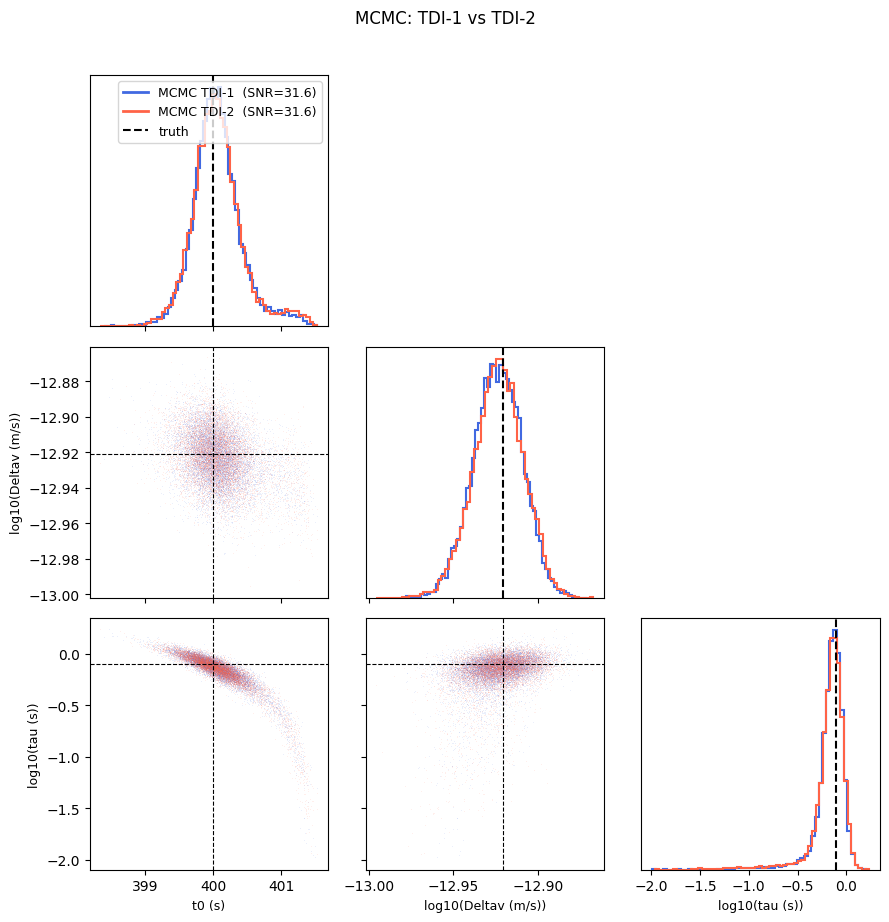

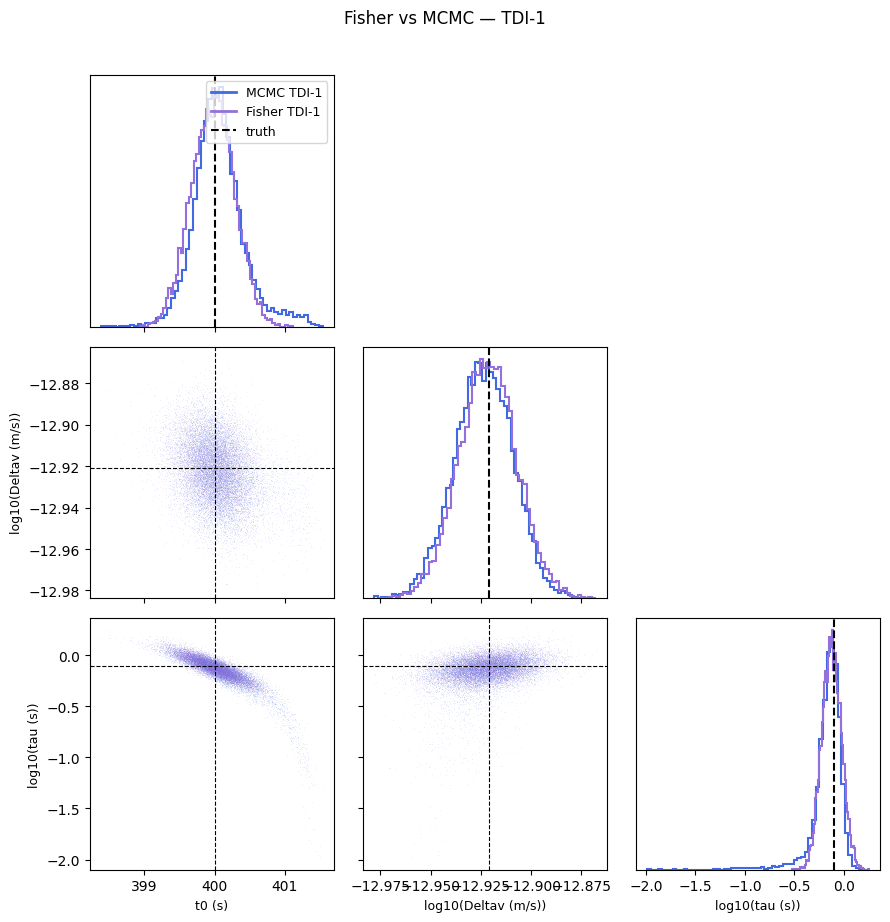

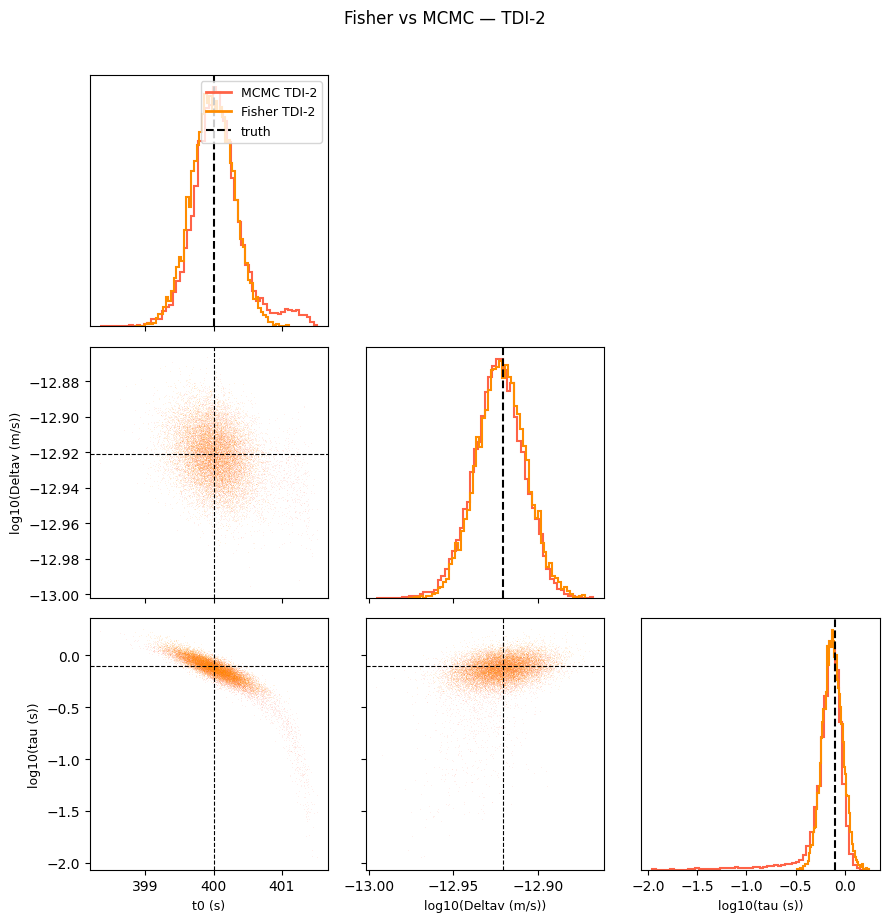

In [14]:
rng = np.random.default_rng(42)
N_FISH = len(chain1)

# Draw samples from Fisher Gaussian in [t0, logDeltav, logTau], centred at MAP
xi_fish1 = rng.multivariate_normal(np.array(xi_map1), np.array(C1_fish), N_FISH)
xi_fish2 = rng.multivariate_normal(np.array(xi_map2), np.array(C2_fish), N_FISH)

def to_plot_coords(xi_arr):
    """[t0, logDeltav, logTau] -> [t0, Deltav, tau] for the corner plots."""
    return np.column_stack([xi_arr[:, 0],
                            np.exp(xi_arr[:, 1]),
                            np.exp(xi_arr[:, 2])])

sp_fish1 = to_plot_coords(xi_fish1)
sp_fish2 = to_plot_coords(xi_fish2)

THIN_F = THIN  # same thinning factor as MCMC chains
sp_fish1 = sp_fish1[::THIN_F]
sp_fish2 = sp_fish2[::THIN_F]

# ── Plot 1: MCMC TDI-1 vs MCMC TDI-2 (same as Section 7) ─────────────────
fig1 = corner_plot(
    [s1, s2],
    [f'MCMC TDI-1  (SNR={snr1:.1f})', f'MCMC TDI-2  (SNR={snr2:.1f})'],
    ['royalblue', 'tomato'],
    plot_names, plot_truths, log_axes={1, 2})
fig1.suptitle('MCMC: TDI-1 vs TDI-2', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ── Plot 2: MCMC TDI-1 vs Fisher TDI-1 ────────────────────────────────────
fig2 = corner_plot(
    [s1, sp_fish1],
    ['MCMC TDI-1', 'Fisher TDI-1'],
    ['royalblue', 'mediumpurple'],
    plot_names, plot_truths, log_axes={1, 2})
fig2.suptitle('Fisher vs MCMC — TDI-1', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

# ── Plot 3: MCMC TDI-2 vs Fisher TDI-2 ────────────────────────────────────
fig3 = corner_plot(
    [s2, sp_fish2],
    ['MCMC TDI-2', 'Fisher TDI-2'],
    ['tomato', 'darkorange'],
    plot_names, plot_truths, log_axes={1, 2})
fig3.suptitle('Fisher vs MCMC — TDI-2', y=1.02, fontsize=12)
plt.tight_layout(); plt.show()